In [1]:
import shap
import pandas as pd
from sklearn.preprocessing import StandardScaler

from joblib import load

model = load('xgb_best.joblib_TA.dat')

X = pd.read_csv("X_train_42.csv")
X = X.drop(['Date','Latitude [N]','Longitude [E]'],axis=1)
# y = pd.read_csv("y_train42.csv")
# X_test = pd.read_csv("X_test42.csv")
# y_test = pd.read_csv("y_test42.csv")

sc = StandardScaler()
X = sc.fit_transform(X)
# X_test = sc.transform(X_test)
# X = X.drop(['Lon','Lat'],axis=1)
# X_test = X_test.drop(['Lon','Lat'],axis=1)

# df = pd.read_csv('Final_data_alldata_before_normal.csv')

# df = df.drop(['Lon','Lat','pCO2'],axis=1)

In [2]:
# df.head()

In [3]:
explainer = shap.KernelExplainer(model.predict,X)
# expl1 = shap.TreeExplainer(model)

Using 890 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


In [4]:
shap_values = explainer.shap_values(X,tree_limit=-1)
# shap_values = explainer.shap_values(X)

  0%|          | 0/890 [00:00<?, ?it/s]

In [5]:
shap_values

array([[-21.76891214, -90.37304237,  12.52794674],
       [ 12.40321603, -47.77310864,  21.56008406],
       [ -4.84719462, 121.8153324 ,   1.25305953],
       ...,
       [ 28.6371743 , 124.60330692,  -5.86083664],
       [ -4.04387276, 124.58171565,  26.76245597],
       [ 14.3601952 , 133.08986762,   8.7550212 ]])

In [6]:
import matplotlib.pyplot as plt

In [7]:
import numpy as np

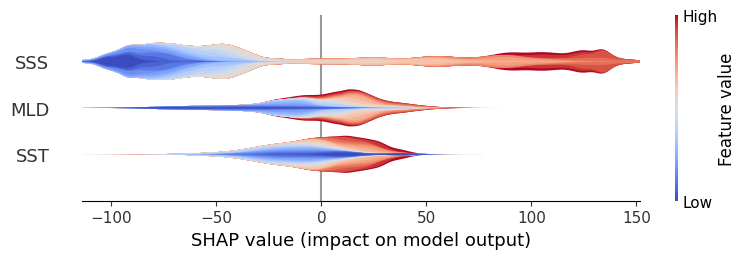

In [8]:
plt.figure(figsize=(10, 18))
shap.summary_plot(shap_values,X,feature_names=["SST","SSS","MLD"],plot_type='layered_violin',show=False)
plt.show()

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


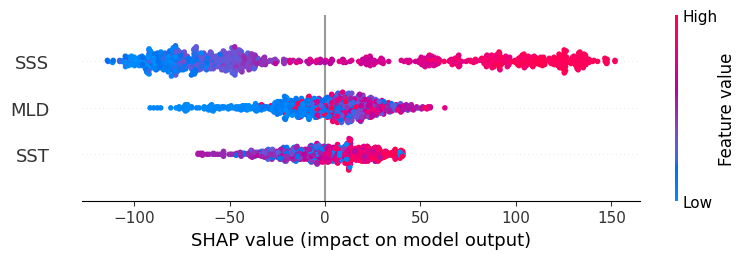

In [11]:
shap.summary_plot(shap_values,X,feature_names=["SST","SSS","MLD"],show=False)

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


In [36]:
shap_interaction_values

array([[[-22.937864  ,  -2.3872795 ,   0.5858407 ],
        [ -2.3872805 , -80.27876   ,  -5.726227  ],
        [  0.585845  ,  -5.726227  ,  19.418934  ]],

       [[ 12.1959715 ,   1.92589   ,  -2.417017  ],
        [  1.9258943 , -49.241966  ,  -1.634551  ],
        [ -2.417015  ,  -1.6345615 ,  28.220573  ]],

       [[-21.398195  ,   6.074646  ,   8.270433  ],
        [  6.0746465 , 118.31729   ,  -3.8736153 ],
        [  8.270437  ,  -3.8736305 ,   1.3267479 ]],

       ...,

       [[ 18.972713  ,   0.15709305,   7.1663885 ],
        [  0.15708542, 117.16121   ,   3.8949893 ],
        [  7.1663837 ,   3.8949585 , -18.2245    ]],

       [[-24.570559  ,   3.142826  ,  12.529933  ],
        [  3.142829  , 129.38655   ,  -8.849956  ],
        [ 12.529936  ,  -8.849995  ,  28.362406  ]],

       [[ 10.12707   ,   5.545124  ,  -5.48151   ],
        [  5.545148  , 129.98506   ,  -8.2850065 ],
        [ -5.481512  ,  -8.285011  ,  27.207333  ]]], dtype=float32)

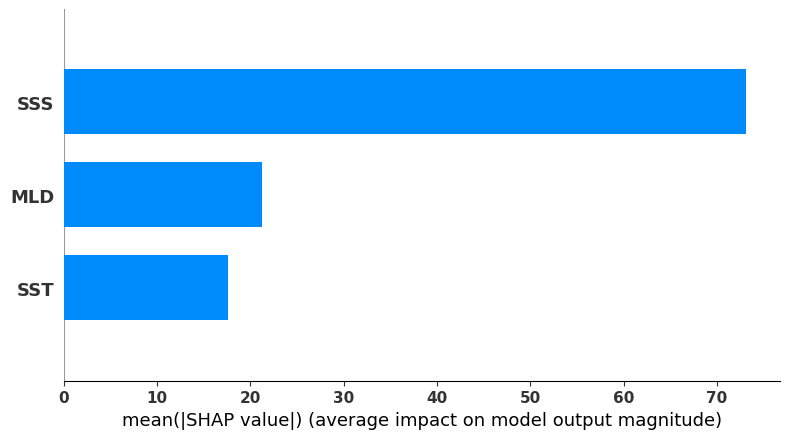

In [33]:
import matplotlib.pyplot as plt
plt.rcParams["font.weight"] = "bold"
# plt.figure(figsize=(16,16))
shap.summary_plot(shap_values,X,feature_names=["SST","SSS","MLD"],plot_type='bar',plot_size=1,color_bar_label='Magnitude of model input variables',show=False)
# plt.xlabel('SHAP values (Impact on TA (\u03BCmol kg$^{-1}$))',fontweight='bold')
# plt.show()
# plt.savefig("SHAP_TA.png",dpi=600,orientation='potrait', bbox_inches='tight')

In [12]:
# shap_interaction_values = expl1.shap_interaction_values(X)
# shap_interaction_values[0]



In [13]:
# interactive_term = pd.DataFrame(shap_interaction_values[0])

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


In [38]:
X1 = pd.DataFrame()
X1['SST'] = X[0]
X1['SSS'] = X[1]
X1['MLD'] = X[2]

In [41]:
# Compute and visualize interaction effects
shap_interaction_values = shap.TreeExplainer(model).shap_interaction_values(X1)

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


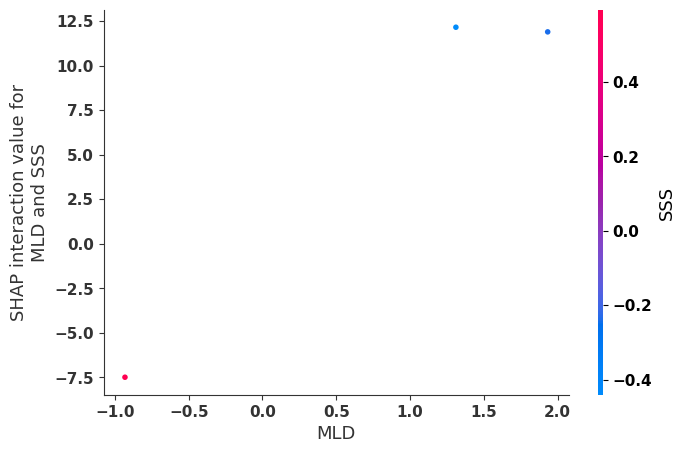

In [21]:
# # Plot individual feature contributions
# shap.summary_plot(shap_values, X, plot_type="bar", show=True)

# # Compute and visualize interaction effects
# shap_interaction_values = shap.TreeExplainer(model).shap_interaction_values(X)

# # Plot interaction effects using SHAP summary
# shap.summary_plot(shap_interaction_values, X, show=True)

# Visualize specific feature interactions (e.g., SST and SSS)
# shap.dependence_plot(('MLD', 'SSS'), shap_interaction_values, X1, interaction_index='SSS')

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


IndexError: tuple index out of range

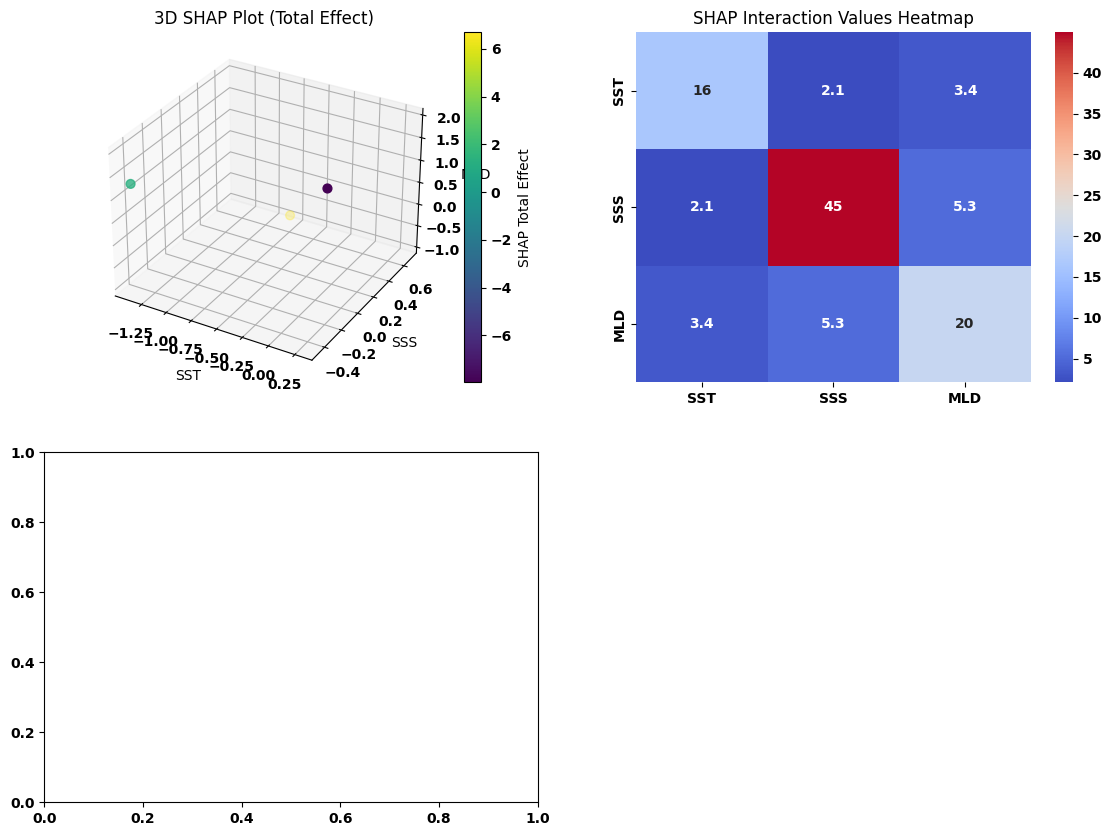

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import shap
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Assuming X is your input dataframe
explainer = shap.Explainer(model, X1)
shap_values = explainer(X1)

# Calculate interaction values using TreeExplainer
shap_interaction_values = shap.TreeExplainer(model).shap_interaction_values(X1)

# Extract values for 3D visualization
SST = X1['SST']
SSS = X1['SSS']
MLD = X1['MLD']
shap_sum = np.sum(shap_values.values, axis=1)
interaction_effects = np.mean(np.abs(shap_interaction_values), axis=0)

# ---- Plotting ----
fig = plt.figure(figsize=(14, 10))

# 3D Scatter Plot
ax = fig.add_subplot(221, projection='3d')
sc = ax.scatter(SST, SSS, MLD, c=shap_sum, cmap='viridis', s=40)
ax.set_xlabel('SST')
ax.set_ylabel('SSS')
ax.set_zlabel('MLD')
ax.set_title('3D SHAP Plot (Total Effect)')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('SHAP Total Effect')

# Interaction Heatmap
ax2 = fig.add_subplot(222)
sns.heatmap(interaction_effects, annot=True, cmap='coolwarm', xticklabels=X1.columns, yticklabels=X1.columns)
ax2.set_title('SHAP Interaction Values Heatmap')

# 2D Projection for SST vs SSS
ax3 = fig.add_subplot(223)
sc2 = ax3.scatter(SST, SSS, c=shap_values[:, X1.columns.get_loc('SST')], cmap='plasma', s=20)
ax3.set_xlabel('SST')
ax3.set_ylabel('SSS')
ax3.set_title('SHAP Individual Effect for SST')
cbar2 = plt.colorbar(sc2, ax=ax3)
cbar2.set_label('SHAP SST Effect')

# 2D Projection for MLD vs SSS
ax4 = fig.add_subplot(224)
sc3 = ax4.scatter(MLD, SSS, c=shap_values[:, X1.columns.get_loc('MLD')], cmap='inferno', s=20)
ax4.set_xlabel('MLD')
ax4.set_ylabel('SSS')
ax4.set_title('SHAP Individual Effect for MLD')
cbar3 = plt.colorbar(sc3, ax=ax4)
cbar3.set_label('SHAP MLD Effect')

plt.tight_layout()
plt.show()
